In [1]:
from tem import world
from pathlib import Path
import itertools
import polars as pl
import seaborn as sns
from tbparse import SummaryReader
config_file = "../envs/mckenzie2024.json"
out_dir = Path("~/Dropbox/work/tem/McKenzie").expanduser() / "study-4"
out_dir.mkdir(exist_ok=True)

In [2]:
design = world.design_mckenzie(config_file)
nodes = (
    ["".join(c) for c in itertools.product(["C1", "C2"], ["AB", "BA", "CD", "DC"])]
    + ["".join(c) for c in itertools.product(["C1", "C2"], ["L", "R"], ["A", "B", "C", "D"], ["R", "N"])]
)
n_runs = 10
for run in range(1, n_runs + 1):
    world.learn_mckenzie(design, nodes, out_dir, run)

In [3]:
subject = "001"
reader = SummaryReader(str(out_dir))
df = (
    pl.DataFrame(reader.scalars)
    .with_columns(
        subject=pl.lit(subject),
        run=pl.col("value").cum_count().over(pl.col("step")),
    )
    .with_columns(
        smooth_value=pl.col("value").rolling_mean(window_size=50).over("tag", "run"),
    )
)

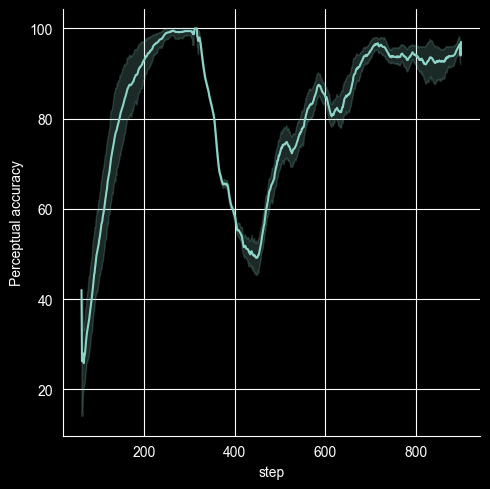

In [4]:
g = sns.relplot(
    df.filter(pl.col("tag") == "Accuracies/p"),
    x="step",
    y="smooth_value",
    kind="line",
)
g.set(ylabel="Perceptual accuracy")

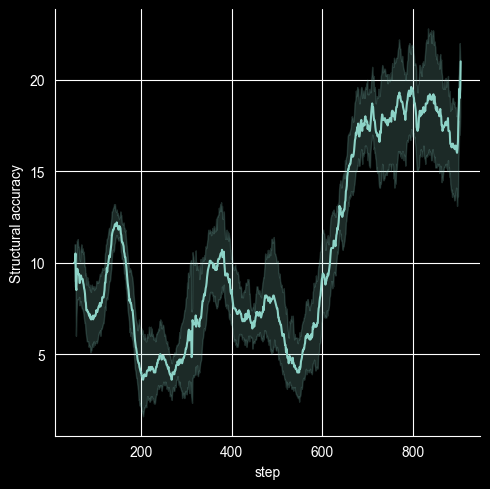

In [5]:
g = sns.relplot(
    df.filter(pl.col("tag") == "Accuracies/g"),
    x="step",
    y="smooth_value",
    kind="line",
)
g.set(ylabel="Structural accuracy")